# Sentiment Analysiس: Food Delivery App Reviews

Complete the tasks in each section.

## Step 1: Import Libraries

In [25]:
# TODO: Import the libraries needed for:
# - pandas
# - re
# - matplotlib.pyplot
# - train_test_split
# - TfidfVectorizer
# - MultinomialNB
# - accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import pandas as pd
import re
import matplotlib.pyplot as plt
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay



## Step 2: Load the Dataset

In [48]:
# TODO: Read the file food_delivery_sentiment_reviews.csv into a dataframe called df
# Then print the shape and the first 5 rows
df = pd.read_csv("dataset/food_delivery_sentiment_reviews.csv")
print(df.head())
print(df.shape)


  review_id                                               text  sentiment
0      N012  My order was canceled without warning after I ...          0
1      P024  Solid app for late-night orders, and support a...          1
2      P005  The interface is simple, the coupons worked, a...          1
3      N025  I regret using this app tonight because everyt...          0
4      N006  Terrible experience; the app froze and then de...          0
(50, 3)


## Step 3: Explore the Dataset

sentiment
0    25
1    25
Name: count, dtype: int64


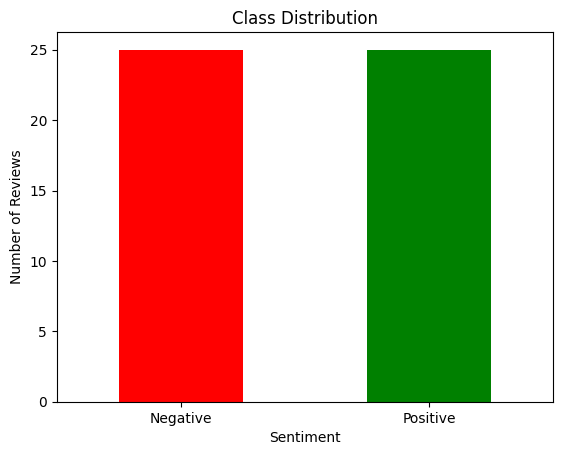

In [52]:
# TODO:
# 1. Show how many reviews belong to each sentiment class
# 2. Create a bar chart for the class distribution

sentiment_counts = df["sentiment"].value_counts().sort_index()
print(sentiment_counts)

sentiment_counts.index = ["Negative", "Positive"]
sentiment_counts.plot(kind="bar", color=["red", "green"])
plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

## Step 4: Clean the Text

In [31]:
# TODO:
# 1. Write a function called clean_text(text)
# 2. Convert text to lowercase
# 3. Remove punctuation / special characters
# 4. Remove extra spaces
# 5. Create a new column called clean_text

def clean_text(text):
    # Remove punctuation
    lower_text = text.lower()
    remove_punctuation = lower_text.translate(str.maketrans('', '', string.punctuation))
    remove_special = re.sub(r'[^a-z\s]', '', remove_punctuation)
    return re.sub(r"\s+", " ", remove_special).strip()

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head()

,text,clean_text
0,My order was canceled without warning after I ...,my order was canceled without warning after i ...
1,"Solid app for late-night orders, and support a...",solid app for latenight orders and support act...
2,"The interface is simple, the coupons worked, a...",the interface is simple the coupons worked and...
3,I regret using this app tonight because everyt...,i regret using this app tonight because everyt...
4,Terrible experience; the app froze and then de...,terrible experience the app froze and then del...


## Step 5: Shuffle the Data

In [32]:
# TODO: Shuffle the dataframe using sample(frac=1, random_state=42).reset_index(drop=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print("Shuffled!")


Shuffled!


## Step 6: Prepare Features and Labels

In [33]:
# TODO:
# Set X to the clean_text column
# Set y to the sentiment column
# Print one sample review and its label

X = df["clean_text"]
y = df["sentiment"]

print(X.iloc[0])
print("Label:", y.iloc[0])


i liked the recommendations and the delivery instructions were followed
Label: 1


## Step 7: Split the Data

In [34]:
# TODO:
# Split the data into training and testing sets
# Use test_size=0.25, random_state=42, and stratify=y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print("Split the data")
print("Training size:", len(X_train))
print("Testing size:", len(X_test))


Split the data
Training size: 37
Testing size: 13


## Step 8: Convert Text to TF-IDF

In [49]:
# TODO:
# 1. Create a TfidfVectorizer with stop_words="english"
# 2. Fit on X_train and transform X_train
# 3. Transform X_test
# 4. Print the matrix shapes

vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Feature matrix shape:", X_train_vec.shape)
print("Feature matrix shape:", X_test_vec.shape)

Feature matrix shape: (37, 168)
Feature matrix shape: (13, 168)


## Step 9: Train the Model

In [38]:
# TODO:
# Create a MultinomialNB model
# Train it using the TF-IDF training data

model = MultinomialNB()
model.fit(X_train_vec, y_train)
print("Trained")

Trained


## Step 10: Make Predictions and Evaluate

In [43]:
# TODO:
# 1. Predict on X_test_tfidf
# 2. Print the accuracy
# 3. Print the classification report

y_pred = model.predict(X_test_vec)
print("Sample predictions:", y_pred[:10])

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Sample predictions: [1 0 0 0 1 1 1 1 0 1]
Accuracy: 0.7692307692307693
              precision    recall  f1-score   support

           0       0.83      0.71      0.77         7
           1       0.71      0.83      0.77         6

    accuracy                           0.77        13
   macro avg       0.77      0.77      0.77        13
weighted avg       0.78      0.77      0.77        13



## Step 11: Display the Confusion Matrix

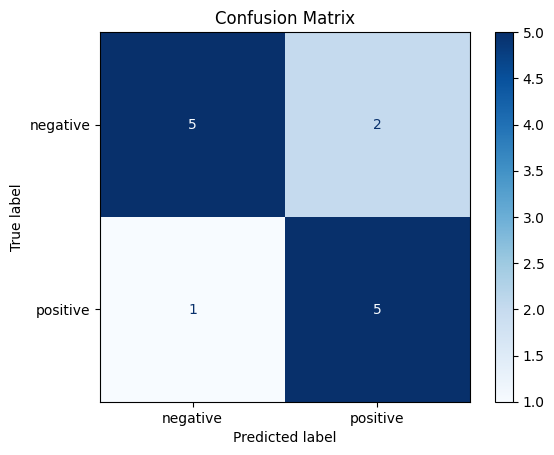

In [55]:
# TODO:
# Build and display a confusion matrix with labels:
# ["negative", "positive"]

disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["negative", "positive"], cmap="Blues")

plt.title("Confusion Matrix")
plt.show()


## Step 12: Try New Reviews

In [50]:
# TODO:
# Predict the sentiment of these three reviews:
# 1. "The app was easy to use and my order came early."
# 2. "I waited forever and half the food was missing."
# 3. "Customer support helped me quickly after a payment issue."
new_reviews = [
    "The app was easy to use and my order came early.",
    "I waited forever and half the food was missing.",
    "Customer support helped me quickly after a payment issue."
]

# Clean the new reviews
cleaned_reviews = [clean_text(review) for review in new_reviews]

# Convert to TF-IDF using the same fitted vectorizer
new_reviews_tfidf = vectorizer.transform(cleaned_reviews)

# Predict sentiment
predictions = model.predict(new_reviews_tfidf)

# Show results
for review, prediction in zip(new_reviews, predictions):
    label = "positive" if prediction == 1 else "negative"
    print(f"Review: {review}")
    print(f"Predicted sentiment: {label}")
    print()

Review: The app was easy to use and my order came early.
Predicted sentiment: positive

Review: I waited forever and half the food was missing.
Predicted sentiment: negative

Review: Customer support helped me quickly after a payment issue.
Predicted sentiment: positive

